# MLC Noise Injection Visualization
Comparison of noise behavior for different cell bit widths.
- 6 total bits with 2-bit cells (3 cells)
- 6 total bits with 3-bit cells (2 cells)

In [62]:
import torch
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [63]:
def injection_error_mlc(params, sigma=0.05, shift=0.02, bits=6, cell_bits=2, eps=1e-12):
    weight_nz = (params.abs() > eps).float()
    scale = params.abs().max().clamp(min=eps)
    sign = torch.sign(params)
    w01 = (params.abs() / scale).clamp(0.0, 1.0)

    qmax = (1 << bits) - 1
    q = torch.round(w01 * qmax).to(torch.int64)
    num_cells = bits // cell_bits
    cell_max = (1 << cell_bits) - 1

    q_recon = torch.zeros_like(w01)
    cell_contrib = []

    for i in range(num_cells):
        shift_bits = i * cell_bits
        bit_sig = 1 << shift_bits
        cell_int = (q >> shift_bits) & cell_max
        cell_val = cell_int.float()

        noise = torch.randn_like(cell_val) * sigma * cell_max 
        shift_term = shift * cell_max 
        noisy_cell = torch.clamp(cell_val + noise - shift_term, 0.0, float(cell_max))

        contrib = (noisy_cell - cell_val) * float(bit_sig) / float(qmax)
        cell_contrib.append(contrib)
        q_recon += noisy_cell * float(bit_sig)

    w01_noisy = (q_recon / float(qmax)).clamp(0.0, 1.0)
    w_noisy = torch.clamp(w01_noisy * sign, -1.0, 1.0) * scale
    return w_noisy, cell_contrib

In [64]:
def injection_error_mlc(params, sigma=0.01, shift=0.00, bits=4, cell_bits=2):

    scale = params.abs().max()
    sign = torch.sign(params)
    w01 = params.abs() / scale

    qmax = (1 << bits) - 1
    q = torch.round(w01 * qmax).to(torch.int64)
    num_cells = bits // cell_bits
    cell_max = (1 << cell_bits) - 1

    q_recon = torch.zeros_like(w01)
    cell_contrib = []

    for i in range(num_cells):
        shift_bits = i * cell_bits
        bit_sig = 1 << shift_bits
        cell_int = (q >> shift_bits) & cell_max
        cell_val = cell_int.float()

        noise = torch.randn_like(cell_val) * sigma * cell_max 
        shift_term = shift * cell_max 
        noisy_cell = cell_val + noise - shift_term

        contrib = (noisy_cell - cell_val) * float(bit_sig) / float(qmax)
        cell_contrib.append(contrib)
        q_recon += noisy_cell * float(bit_sig)

    w01_noisy = q_recon / float(qmax)
    w_noisy = w01_noisy * scale
    return w_noisy, cell_contrib

In [65]:
bits = 4
levels = 2**bits          
values = torch.arange(levels) / (levels - 1)  

weights = values.repeat_interleave(1000)

In [66]:

noisy_2bit, contrib_2bit = injection_error_mlc(weights, cell_bits=2)
noisy_4bit, contrib_4bit = injection_error_mlc(weights, cell_bits=4)

## Weight Error Distribution

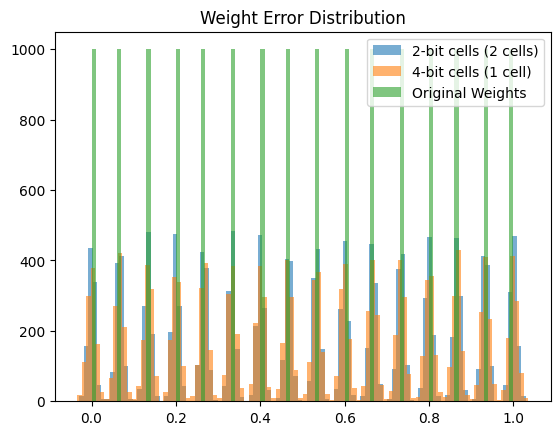

In [67]:
plt.figure()
plt.hist(noisy_2bit.numpy(), bins=100, alpha=0.6, label='2-bit cells (2 cells)')
plt.hist(noisy_4bit.numpy(), bins=100, alpha=0.6, label='4-bit cells (1 cell)')
plt.hist(weights.numpy(), bins=100, alpha=0.6, label='Original Weights')
plt.legend()
plt.title('Weight Error Distribution')
plt.show()

## Per-Cell Error Contribution

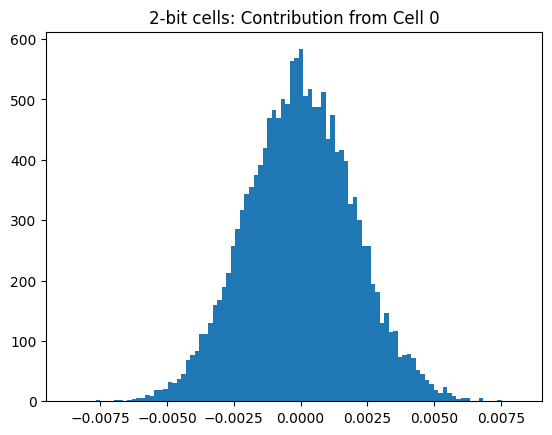

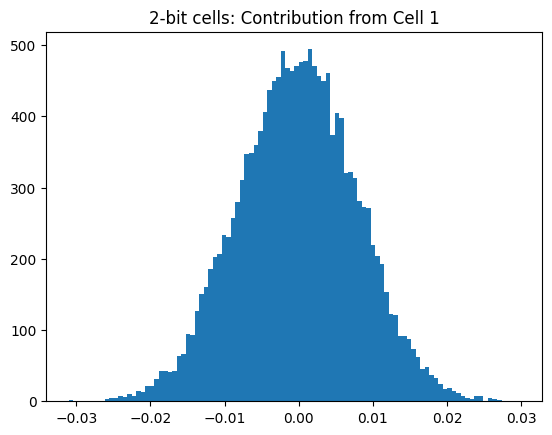

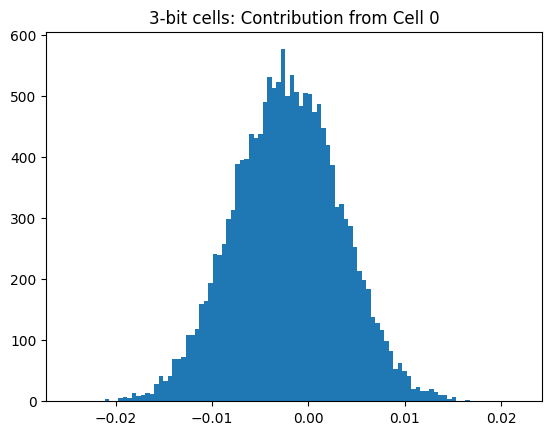

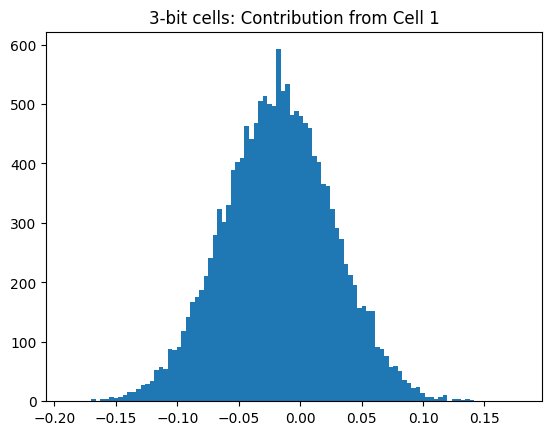

In [68]:
for i, c in enumerate(contrib_2bit):
    plt.figure()
    plt.hist(c.numpy(), bins=100)
    plt.title(f'2-bit cells: Contribution from Cell {i}')
    plt.show()

for i, c in enumerate(contrib_3bit):
    plt.figure()
    plt.hist(c.numpy(), bins=100)
    plt.title(f'3-bit cells: Contribution from Cell {i}')
    plt.show()